In [1]:
import numpy as np
from scipy.stats import norm
from numpy.random import normal, uniform
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import time
from scipy.integrate import quad

# Q1

### Functions for computing analytical price and Greeks

In [10]:
S0 = 100
K = 110
B = 90
r = 0.05
T = 1
sigma = 0.5

def delta1(T, z, sigma):
    return 1/(sigma*np.sqrt(T)) * (np.log(z) + (r+0.5*sigma**2)*T)
def delta2(T, z, sigma):
    return 1/(sigma*np.sqrt(T)) * (np.log(z) + (r-0.5*sigma**2)*T)
def d_delta_dz(T, z, sigma):
    return (1/(sigma*np.sqrt(T)))*(1/z)
def d_delta_ds1(T, z, sigma):
    return -1/(sigma*sigma*np.sqrt(T))*(np.log(z) + (r+0.5*sigma**2)*T) + \
            1/(sigma*np.sqrt(T)) * (sigma*T)
def d_delta_ds2(T, z, sigma):
    return -1/(sigma*sigma*np.sqrt(T))*(np.log(z) + (r-0.5*sigma**2)*T) + \
            1/(sigma*np.sqrt(T)) * (-sigma*T)
        
def BS_down_and_out_price(S0, K, B, r, T, sigma):
    if S0 <= B:
        return 0
    term1 = S0*norm.cdf(delta1(T, S0/K, sigma))-K*np.exp(-r*T)*norm.cdf(delta2(T, S0/K, sigma))
    term2 = -B*(B/S0)**(2*r/(sigma**2)) * norm.cdf(delta1(T, B*B/(K*S0), sigma))
    term3 = K*np.exp(-r*T)*(S0/B)**(1-2*r/(sigma**2)) * norm.cdf(delta2(T, B*B/(K*S0), sigma))
    return term1+term2+term3
    
def BS_down_and_out_delta(S0, K, B, r, T, sigma):
    if S0 <= B:
        return 0
    term1 = norm.cdf(delta1(T, S0/K, sigma)) + S0*norm.pdf(delta1(T, S0/K, sigma))*d_delta_dz(T, S0/K, sigma)/K - \
            K*np.exp(-r*T)*norm.pdf(delta2(T, S0/K, sigma))*d_delta_dz(T, S0/K, sigma)/K
    term2 = -B*(2*r/(sigma**2))*(B/S0)**(2*r/(sigma**2)-1) * (-B/(S0*S0)) * norm.cdf(delta1(T, B*B/(K*S0), sigma)) + \
            -B*(B/S0)**(2*r/(sigma**2)) * norm.pdf(delta1(T, B*B/(K*S0), sigma)) * d_delta_dz(T, B*B/(K*S0), sigma) * (-B*B/(K*S0*S0))
    term3 = K*np.exp(-r*T)*((1-2*r/(sigma**2))/B)*(S0/B)**(-2*r/(sigma**2)) * norm.cdf(delta2(T, B*B/(K*S0), sigma)) + \
            K*np.exp(-r*T)*(S0/B)**(1-2*r/(sigma**2)) * norm.pdf(delta2(T, B*B/(K*S0), sigma)) * d_delta_dz(T, B*B/(K*S0), sigma) * (-B*B/(K*S0*S0))
    return term1+term2+term3

def BS_down_and_out_vega(S0, K, B, r, T, sigma):
    if S0 <= B:
        return 0
    term1 = S0*norm.pdf(delta1(T, S0/K, sigma))*d_delta_ds1(T, S0/K, sigma) - \
            K*np.exp(-r*T)*norm.pdf(delta2(T, S0/K, sigma))*d_delta_ds2(T, S0/K, sigma)
    term2 = -B*(B/S0)**(2*r/(sigma**2)) * np.log(B/S0) * (-4*r/(sigma**3)) * norm.cdf(delta1(T, B*B/(K*S0), sigma)) - \
            B*(B/S0)**(2*r/(sigma**2)) * norm.pdf(delta1(T, B*B/(K*S0), sigma)) * d_delta_ds1(T, B*B/(K*S0), sigma)
    term3 = K*np.exp(-r*T)*(S0/B)**(1-2*r/(sigma**2)) * np.log(S0/B) * (4*r/(sigma**3)) * norm.cdf(delta2(T, B*B/(K*S0), sigma)) + \
            K*np.exp(-r*T)*(S0/B)**(1-2*r/(sigma**2)) * norm.pdf(delta2(T, B*B/(K*S0), sigma)) * d_delta_ds2(T, B*B/(K*S0), sigma)
    return term1+term2+term3

B = 90
true_price = BS_down_and_out_price(S0, K, B, r, T, sigma)
true_delta = BS_down_and_out_delta(S0, K, B, r, T, sigma)
true_vega = BS_down_and_out_vega(S0, K, B, r, T, sigma)
print('True Price: ', true_price)
print('True Delta: ', true_delta)
print('True Vega: ', true_vega)

True Price:  8.595814223136038
True Delta:  0.8493573084795619
True Vega:  4.550660734464294


In [6]:
np.random.seed(0)

N = 100000000
epsilon = 0.01

# Linear approximation of digital payoff function
def linear_approx(M_T):
    if M_T > B+epsilon/2: 
        return 1
    elif M_T < B-epsilon/2:
        return 0
    else:
        return (M_T-(B-epsilon/2))/epsilon
v_linear_approx = np.vectorize(linear_approx, otypes=[np.float64])
# Derivative of linear approximation of digital payoff function
def linear_approx_derivative(M_T):
    if M_T > B+epsilon/2 or M_T < B-epsilon/2: 
        return 0
    else:
        return 1/epsilon
v_linear_approx_derivative = np.vectorize(linear_approx_derivative, otypes=[np.float64])

W_Ts = normal(0, np.sqrt(T), size=N)
Us = uniform(0, 1, size=N)
X_Ts = (r-0.5*sigma**2)*T + sigma*W_Ts
S_Ts = S0*np.exp(X_Ts)
min_Xs = 0.5*(X_Ts-np.sqrt(X_Ts**2 - 2*(sigma**2)*T*np.log(Us)))
M_Ts = S0*np.exp(min_Xs)
payoffs = np.maximum(S_Ts-K, 0)

approxs = v_linear_approx(M_Ts)
approx_derivatives = v_linear_approx_derivative(M_Ts)
deltas = (S_Ts >= K)*(S_Ts/S0)*approxs + payoffs*approx_derivatives*(M_Ts/S0)
dminX_dsigmas = 0.5*(-sigma*T + W_Ts)-0.5*(X_Ts*(-sigma*T+W_Ts)-2*sigma*T*np.log(Us))/np.sqrt(X_Ts**2 - 2*(sigma**2)*T*np.log(Us))
vegas = (S_Ts >= K)*S_Ts*(-sigma*T + W_Ts)*approxs + payoffs*approx_derivatives*M_Ts*dminX_dsigmas
del approxs, approx_derivatives, dminX_dsigmas

deltas, vegas = np.exp(-r*T)*np.array(deltas), np.exp(-r*T)*np.array(vegas)

In [15]:
print(f'Estimated Delta: {np.round(np.mean(deltas), 5)} ({np.round(100*(np.mean(deltas)-true_delta)/true_delta, 4)}%), std: {np.round(np.std(deltas)/np.sqrt(N), 3)}')
print(f'Estimated Vega: {np.round(np.mean(vegas), 5)} ({np.round(100*(np.mean(vegas)-true_vega)/true_vega, 4)}%), std: {np.round(np.std(vegas)/np.sqrt(N), 3)}')

Estimated Delta: 0.85 (0.0758%), std: 0.008
Estimated Vega: 4.52208 (-0.6281%), std: 0.189


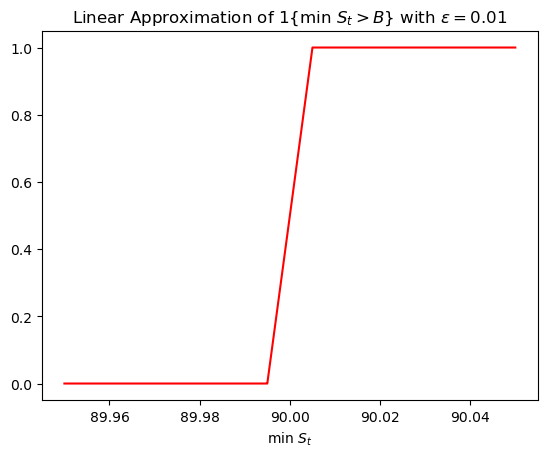

In [8]:
# Plot linear approximation of payoff
plt.plot(np.linspace(89.95, 90.05, 10000), v_linear_approx(np.linspace(89.95, 90.05, 10000)), c='r')
plt.title(r'Linear Approximation of $1\{$min $S_t > B\}$ with ' + rf'$\epsilon={epsilon}$')
plt.xlabel(r'min $S_t$')
plt.savefig('Figures/1_1.png')

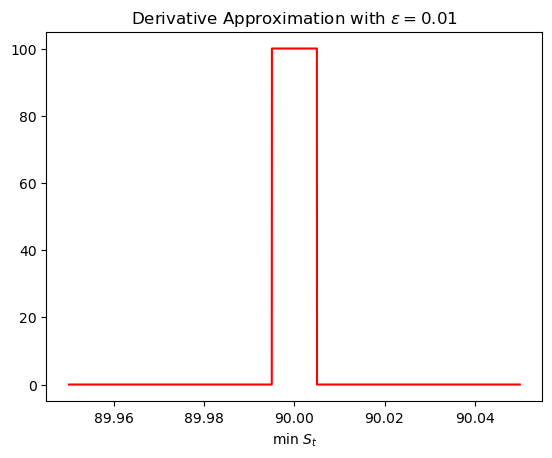

In [9]:
# Plot derivative of linear approximation of payoff
plt.plot(np.linspace(89.95, 90.05, 10000), v_linear_approx_derivative(np.linspace(89.95, 90.05, 10000)), c='r')
plt.title(r'Derivative Approximation with ' + rf'$\epsilon={epsilon}$')
plt.xlabel(r'min $S_t$')
plt.savefig('Figures/1_2.png')

# Multilevel Monte Carlo Path Simulation

### Functions for computing analytical option prices in order to assess accuracy (RMSE)

In [2]:
def Black_Scholes_Call_Price(S0, sigma, r, T, K):
    d1 = np.log(S0/K)/(sigma*np.sqrt(T)) + (r/sigma + sigma/2)*np.sqrt(T)
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)

def Black_Scholes_Digital_Call_Price(S0, sigma, r, T, K):
    d2 = np.log(S0/K)/(sigma*np.sqrt(T)) + (r/sigma - sigma/2)*np.sqrt(T)
    return np.exp(-r*T)*norm.cdf(d2)

def european_call(S):
    return np.maximum(S[:, -1]-K, 0)

def Black_Scholes_Lookback_Call_Price(S0, sigma, r, T, K):
    a_1 = (r+0.5*sigma**2)*T/(sigma*np.sqrt(T))
    a_2 = a_1 - (sigma*np.sqrt(T))
    a_3 = a_1 - 2*r*np.sqrt(T)/sigma
    return S0*norm.cdf(a_1) - S0*np.exp(-r*T)*norm.cdf(a_2) -S0*sigma**2/(2*r)*(norm.cdf(-a_1) - np.exp(-r*T)*norm.cdf(-a_3))

### Closed-form Heston European call price in terms of integrals

In [3]:
def heston_cf(w, s0, v0, vbar, a, vvol, r, rho, t, K):
    alpha = -(w**2)/2 - w*1j/2
    beta = a - rho * vvol * w*1j
    gamma = (vvol**2)/2
    h = np.sqrt(beta**2 - 4 * alpha * gamma)
    r_plus = (beta + h) / (vvol**2)
    r_minus = (beta - h) / (vvol**2)
    g = r_minus/r_plus

    C = a * (r_minus*t - (2/(vvol**2))*np.log((1-g*np.exp(-h*t))/(1-g)))
    D = r_minus * (1-np.exp(-h*t))/(1-g*np.exp(-h*t))
    return np.exp(C * vbar + D * v0 + w * 1j * np.log(s0 * np.exp(r * t)))

def heston_integrand1(w, s0, v0, vbar, a, vvol, r, rho, t, K):
    integrand1 = np.exp(-w*np.log(K)*1j)*heston_cf(w-1j, s0, v0, vbar, a, vvol, r, rho, t, K)
    integrand1 /= w*heston_cf(-1j, s0, v0, vbar, a, vvol, r, rho, t, K)*1j
    return integrand1.real

def heston_integrand2(w, s0, v0, vbar, a, vvol, r, rho, t, K):
    integrand2 = np.exp(-w * np.log(K) * 1j) * heston_cf(w, s0, v0, vbar, a, vvol, r, rho, t, K)
    integrand2 /= w*1j
    return integrand2.real

def heston_price(s0, v0, vbar, a, vvol, r, rho, t, K):
    quad1 = quad(heston_integrand1, 0, 1000, args=(s0, v0, vbar, a, vvol, r, rho, t, K), limit=500)
    quad2 = quad(heston_integrand2, 0, 1000, args=(s0, v0, vbar, a, vvol, r, rho, t, K), limit=500)
    pi1 = 0.5 + (1/np.pi)*quad1[0]
    pi2 = 0.5 + (1/np.pi)*quad2[0]
    return s0*pi1 - K*np.exp(-r*t)*pi2

In [3]:
M = 4
np.random.seed(0)

def simulate_P_l_diff(l, payoff, S0, r, sigma, T, paths):
    # Payoff is a function that takes the price paths as input and outputs an array of option payoffs
    
    steps = M**l
    W_t1 = normal(0, np.sqrt(T/steps), size=(paths, steps))   # Simulate Brownian increments with M^l steps
    S_t1 = np.zeros((paths, steps+1))
    S_t1[:, 0] = S0
    S_t1[:, 1:] = S0 * np.cumprod(1+r*T/steps + sigma*W_t1, axis=1)

    payoffs1 = payoff(S_t1)
    del S_t1
    if l == 0:
        return np.exp(-r*T)*payoffs1, np.exp(-r*T)*payoffs1

    W_t2 = np.zeros((paths, steps//M))
    # Group the Brownian increments in groups of M
    for j in range(M):
        W_t2 += W_t1[:, j::M]
    del W_t1
    S_t2 = np.zeros((paths, steps//M + 1))
    S_t2[:, 0] = S0
    S_t2[:, 1:] = S0 * np.cumprod(1+r*(M*T/steps) + sigma*W_t2, axis=1)
    del W_t2
    payoffs2 = payoff(S_t2)
    del S_t2
    return np.exp(-r*T)*payoffs1, np.exp(-r*T)*(payoffs1-payoffs2)
    

def estimate_price(payoff, model_simulate_P_l_diff, eps=0.001, extrapolation=False, disp=True):
    L = 0
    N_initial = 10**4
    target_error = (1/np.sqrt(2))*(M-1)*eps
    target_error_extrapolation = (1/np.sqrt(2))*(M**2-1)*eps
    P_ls = []
    P_diffs = []
    P_diffs_sum = []
    max_N_ls = np.array([], dtype='int64')
    N_ls = np.array([], dtype='int64')
    V_ls = np.array([])
    h_ls = np.array([])
    while True:
        start = time.time()
        P_l, diff = model_simulate_P_l_diff(L, N_initial)   # Get realisations of P_l and P_l-P_{l-1}
        P_ls.append(P_l)
        P_diffs.append(diff)
        total = np.sum(diff)
        P_diffs_sum.append(total)
        V_ls = np.concatenate((V_ls, [(1/(N_initial-1))*np.sum((diff-total/N_initial)**2)]))   # Initial estimate of V_l using 10^4 paths
        h_ls = np.concatenate((h_ls, [M**(-L)]))
        max_N_ls = np.concatenate((max_N_ls, [N_initial]))
        N_ls = np.concatenate((N_ls, [N_initial]))

        # Prevent V_ls[i] from being 0 (added for digital call under Milstein)
        V_ls[V_ls == 0] = V_ls[V_ls != 0].min()
        
        new_N_ls = np.ceil(2/(eps**2) * np.sqrt(V_ls*h_ls) * np.sum(np.sqrt(V_ls/h_ls))).astype(int)   # Compute optimal values of N_l
        if disp:
            print(new_N_ls)
        for i in range(L+1):
            if new_N_ls[i] > max_N_ls[i]:
                P_l, diff = model_simulate_P_l_diff(i, new_N_ls[i]-max_N_ls[i])   # Simulate more realisations if optimal N_l is higher
                P_ls[i] = np.concatenate((P_ls[i], P_l))
                P_diffs[i] = np.concatenate((P_diffs[i], diff))
                P_diffs_sum[i] += np.sum(P_diffs[i][N_ls[i]:])
                V_ls[i] = np.std(P_diffs[i], ddof=1)**2
            elif new_N_ls[i] > N_ls[i]:
                P_diffs_sum[i] += np.sum(P_diffs[i][N_ls[i]:new_N_ls[i]])
                V_ls[i] = np.std(P_diffs[i][:new_N_ls[i]], ddof=1)**2
            else:
                P_diffs_sum[i] -= np.sum(P_diffs[i][new_N_ls[i]:N_ls[i]])
                V_ls[i] = np.std(P_diffs[i][:new_N_ls[i]], ddof=1)**2
        #N_ls = np.maximum(N_ls, new_N_ls)
        N_ls = new_N_ls
        max_N_ls = np.maximum(max_N_ls, new_N_ls)
        if L >= 2:
            if extrapolation:
                # Check if Richardson termination condition is achieved
                if np.abs(P_diffs_sum[-1]/N_ls[-1] - P_diffs_sum[-2]/(N_ls[-2]*M)) < target_error_extrapolation:
                    if disp:
                        print(f'L = {L} took {time.time()-start} seconds.')
                    P_ls, P_diffs = [elem[:N_ls[i]] for i, elem in enumerate(P_ls)], [elem[:N_ls[i]] for i, elem in enumerate(P_diffs)]
                    return np.sum(P_diffs_sum/N_ls) + (1/(M-1))*P_diffs_sum[-1]/N_ls[-1], V_ls, N_ls, P_ls, P_diffs
            else:
                # Check if termination condition is achieved
                if np.abs(P_diffs_sum[-2]/(N_ls[-2]*M)) < target_error and np.abs(P_diffs_sum[-1]/N_ls[-1]) < target_error:
                    if disp:
                        print(f'L = {L} took {time.time()-start} seconds.')
                    P_ls, P_diffs = [elem[:N_ls[i]] for i, elem in enumerate(P_ls)], [elem[:N_ls[i]] for i, elem in enumerate(P_diffs)]
                    return np.sum(P_diffs_sum/N_ls), V_ls, N_ls, P_ls, P_diffs
        if disp:
            print(f'L = {L} took {time.time()-start} seconds.')
        L += 1

S0 = 1
K = 1
r = 0.05
sigma = 0.2
T = 1

print('No Extrapolation:')
estimated_price, V_ls, N_ls, P_ls, P_diffs = estimate_price(european_call, \
                                                            lambda l, N: simulate_P_l_diff(l, european_call, S0, r, sigma, T, N), \
                                                            eps=0.001, extrapolation=False)
bs_price = Black_Scholes_Call_Price(S0, sigma, r, T, K)
print(f'Estimate: {estimated_price}, Error: {100*(estimated_price-bs_price)/bs_price}%')
print('-'*10)
print('Extrapolation:')
estimated_price, V_ls, N_ls, P_ls, P_diffs = estimate_price(european_call, \
                                                            lambda l, N: simulate_P_l_diff(l, european_call, S0, r, sigma, T, N), \
                                                            eps=0.001, extrapolation=True)
bs_price = Black_Scholes_Call_Price(S0, sigma, r, T, K)
print(f'Estimate: {estimated_price}, Error: {100*(estimated_price-bs_price)/bs_price}%')

No Extrapolation:
[31216]
L = 0 took 0.005017280578613281 seconds.
[42047  3375]
L = 1 took 0.0044705867767333984 seconds.
[52974  4348  1075]
L = 2 took 0.012733936309814453 seconds.
Estimate: 0.10402295100625351, Error: -0.4620648332858376%
----------
Extrapolation:
[32575]
L = 0 took 0.0029642581939697266 seconds.
[42908  3537]
L = 1 took 0.004498958587646484 seconds.
[54330  4730  1152]
L = 2 took 0.013916254043579102 seconds.
Estimate: 0.10515035455030397, Error: 0.6167299883268645%


In [5]:
def plot_graphs(simulate_diff_function, estimate_function, analytical_price_function, epss, save_fig_name, fixed_N=4*(10**6), plot_cost=False):
    log_mean_P_ls, log_mean_P_diffs, ext = [], [], []
    log_var_P_ls, log_var_P_diffs = [], []
    Y_ls = []

    # Top 2 graphs generated with 4*10^6 paths to illustrate convergence properties
    for l in range(5):
        start = time.time()
        P_ls, P_diffs = simulate_diff_function(l, fixed_N)
        log_mean_P_ls.append(np.log(np.abs(np.mean(P_ls)))/np.log(M))
        log_mean_P_diffs.append(np.log(np.abs(np.mean(P_diffs)))/np.log(M))
        log_var_P_ls.append(np.log(np.var(P_ls))/np.log(M))
        log_var_P_diffs.append(np.log(np.var(P_diffs))/np.log(M))
        Y_l = np.mean(P_diffs)
        Y_ls.append(Y_l)
        print(f'l = {l} took {time.time()-start} seconds.')
    Y_ls = np.array(Y_ls)
    ext = np.log(np.abs(Y_ls[2:]-Y_ls[1:-1]/M))/np.log(M)

    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
    if plot_cost:
        fig2, ax = plt.subplots(nrows=1, ncols=1)
    axs = axs.flatten()
    axs[0].plot(range(5), log_var_P_ls, label=r'$P_l$')
    axs[0].plot(range(1, 5), log_var_P_diffs[1:], label=r'$P_l-P_{l-1}$')
    axs[0].scatter(range(5), log_var_P_ls)
    axs[0].scatter(range(1, 5), log_var_P_diffs[1:])
    axs[0].set_ylabel(r'$log_M(Variance)$')
    axs[0].set_xlabel(r'$l$')
    axs[0].xaxis.set_major_locator(ticker.MultipleLocator(1))
    axs[0].legend()
    
    axs[1].plot(range(5), log_mean_P_ls, label=r'$P_l$')
    axs[1].plot(range(1, 5), log_mean_P_diffs[1:], label=r'$P_l-P_{l-1}$')
    axs[1].plot(range(2, 5), ext, c='r', label=r'$Y_l-Y_{l-1}/M$')
    axs[1].scatter(range(5), log_mean_P_ls)
    axs[1].scatter(range(1, 5), log_mean_P_diffs[1:])
    axs[1].scatter(range(2, 5), ext, c='r')
    axs[1].set_ylabel(r'$log_M\mid Mean \mid$')
    axs[1].set_xlabel(r'$l$')
    axs[1].xaxis.set_major_locator(ticker.MultipleLocator(1))
    axs[1].legend()

    Cs, Cs_ext = [], []
    standard_MC_Cs, standard_MC_Cs_ext = [], []

    if analytical_price_function:
        if type(analytical_price_function) == int or type(analytical_price_function) == float:
            analytical_price = analytical_price_function
        else:
            analytical_price = analytical_price_function(S0, sigma, r, T, K)
    for eps in epss:
        start = time.time()
        estimated_price, V_ls, N_ls, P_ls, P_diffs = estimate_function(eps, simulate_diff_function, False)
        temp1 = M**np.arange(len(N_ls))
        Cs.append(N_ls[0] + np.sum((temp1[:-1] + temp1[1:])*N_ls[1:]))
        standard_MC_Cs.append(np.sum((2/(eps)**2) * np.array([np.var(P_l) for P_l in P_ls]) * M**np.arange(len(N_ls))))
        axs[2].plot(np.log(N_ls)/np.log(10), label=rf'$\epsilon={eps}$')
        axs[2].scatter(np.arange(len(N_ls)), np.log(N_ls)/np.log(10))

        if plot_cost:
            ax.plot(np.arange(1, len(N_ls)), N_ls[1:]*(M ** np.arange(1, len(N_ls))), label=rf'$\epsilon={eps}$')
            ax.scatter(np.arange(1, len(N_ls)), N_ls[1:]*(M ** np.arange(1, len(N_ls))))
    
        estimated_price2, V_ls2, N_ls2, P_ls2, P_diffs2 = estimate_function(eps, simulate_diff_function, True)
        temp2 = M**np.arange(len(N_ls2))
        Cs_ext.append(N_ls2[0] + np.sum((temp2[:-1] + temp2[1:])*N_ls2[1:]))
        standard_MC_Cs_ext.append(np.sum((2/(eps)**2) * np.array([np.var(P_l) for P_l in P_ls2]) * M**np.arange(len(N_ls2))))
        if analytical_price_function:
            print(f'Eps = {eps}:')
            print(f'No Ext Estimate: {estimated_price} ({np.round(100*(estimated_price-analytical_price)/analytical_price, 2)}%)', \
                  f'Ext Estimate: {estimated_price2} ({np.round(100*(estimated_price2-analytical_price)/analytical_price, 2)}%)')
            print(f'Time taken: {time.time()-start}')
            print('-'*100)

    print('RMSE/epsilon Ratio: ')
    for eps in epss:
        start = time.time()
        MSE_total, MSE_total_ext = 0, 0
        # Repeat estimation process 10 times to estimate RMSE
        for _ in range(10):
            estimated_price, _, _, _, _ = estimate_function(eps, simulate_diff_function, False)
            MSE_total += (estimated_price-analytical_price)**2

            estimated_price2, _, _, _, _ = estimate_function(eps, simulate_diff_function, True)
            MSE_total_ext += (estimated_price2-analytical_price)**2
        print(f'Eps = {eps}: {np.sqrt(MSE_total/10)/eps}, {np.sqrt(MSE_total_ext/10)/eps} ({time.time()-start} seconds)')

    axs[2].set_ylabel(r'$log_{10}$ $N_l$')
    axs[2].set_xlabel(r'$l$')
    axs[2].xaxis.set_major_locator(ticker.MultipleLocator(1))
    axs[2].legend()
    
    axs[3].loglog(epss, epss**2 * Cs, label='MLMC')
    axs[3].loglog(epss, epss**2 * Cs_ext, label='MLMC Ext')
    axs[3].loglog(epss, epss**2 * standard_MC_Cs, label='Standard MC')
    axs[3].loglog(epss, epss**2 * standard_MC_Cs_ext, label='Standard MC Ext')
    axs[3].scatter(epss, epss**2 * Cs)
    axs[3].scatter(epss, epss**2 * Cs_ext)
    axs[3].scatter(epss, epss**2 * standard_MC_Cs)
    axs[3].scatter(epss, epss**2 * standard_MC_Cs_ext)
    axs[3].set_ylabel(r'$\epsilon^2 \cdot Cost$')
    axs[3].set_xlabel(r'$\epsilon$')
    axs[3].legend()

    # Plot computation cost by level (should be evenly distributed for beta = 1)
    if plot_cost:
        ax.set_xlim(-0.2, ax.get_xlim()[1])
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.set_title(r'Computational Cost $N_l/h_l$ by Level')
        ax.set_xlabel(r'$l$')
        ax.legend()

    fig.tight_layout()
    fig.savefig(save_fig_name+'.pdf', format='pdf')
    if plot_cost:
        fig2.tight_layout()
        fig2.savefig(save_fig_name+'2.pdf', format='pdf')

l = 0 took 0.17275285720825195 seconds.
l = 1 took 0.5416533946990967 seconds.
l = 2 took 1.8586409091949463 seconds.
l = 3 took 7.280059099197388 seconds.
l = 4 took 54.567543506622314 seconds.
Eps = 0.001:
No Ext Estimate: 0.10418140954127768 (-0.31%) Ext Estimate: 0.1045345450096939 (0.03%)
Time taken: 0.029089689254760742
----------------------------------------------------------------------------------------------------
Eps = 0.0005:
No Ext Estimate: 0.10413187412947249 (-0.36%) Ext Estimate: 0.10468532655150832 (0.17%)
Time taken: 0.046584367752075195
----------------------------------------------------------------------------------------------------
Eps = 0.0002:
No Ext Estimate: 0.10463308381609777 (0.12%) Ext Estimate: 0.10468362890081095 (0.17%)
Time taken: 0.27599239349365234
----------------------------------------------------------------------------------------------------
Eps = 0.0001:
No Ext Estimate: 0.10453809053552049 (0.03%) Ext Estimate: 0.1045238864709429 (0.02%)
T

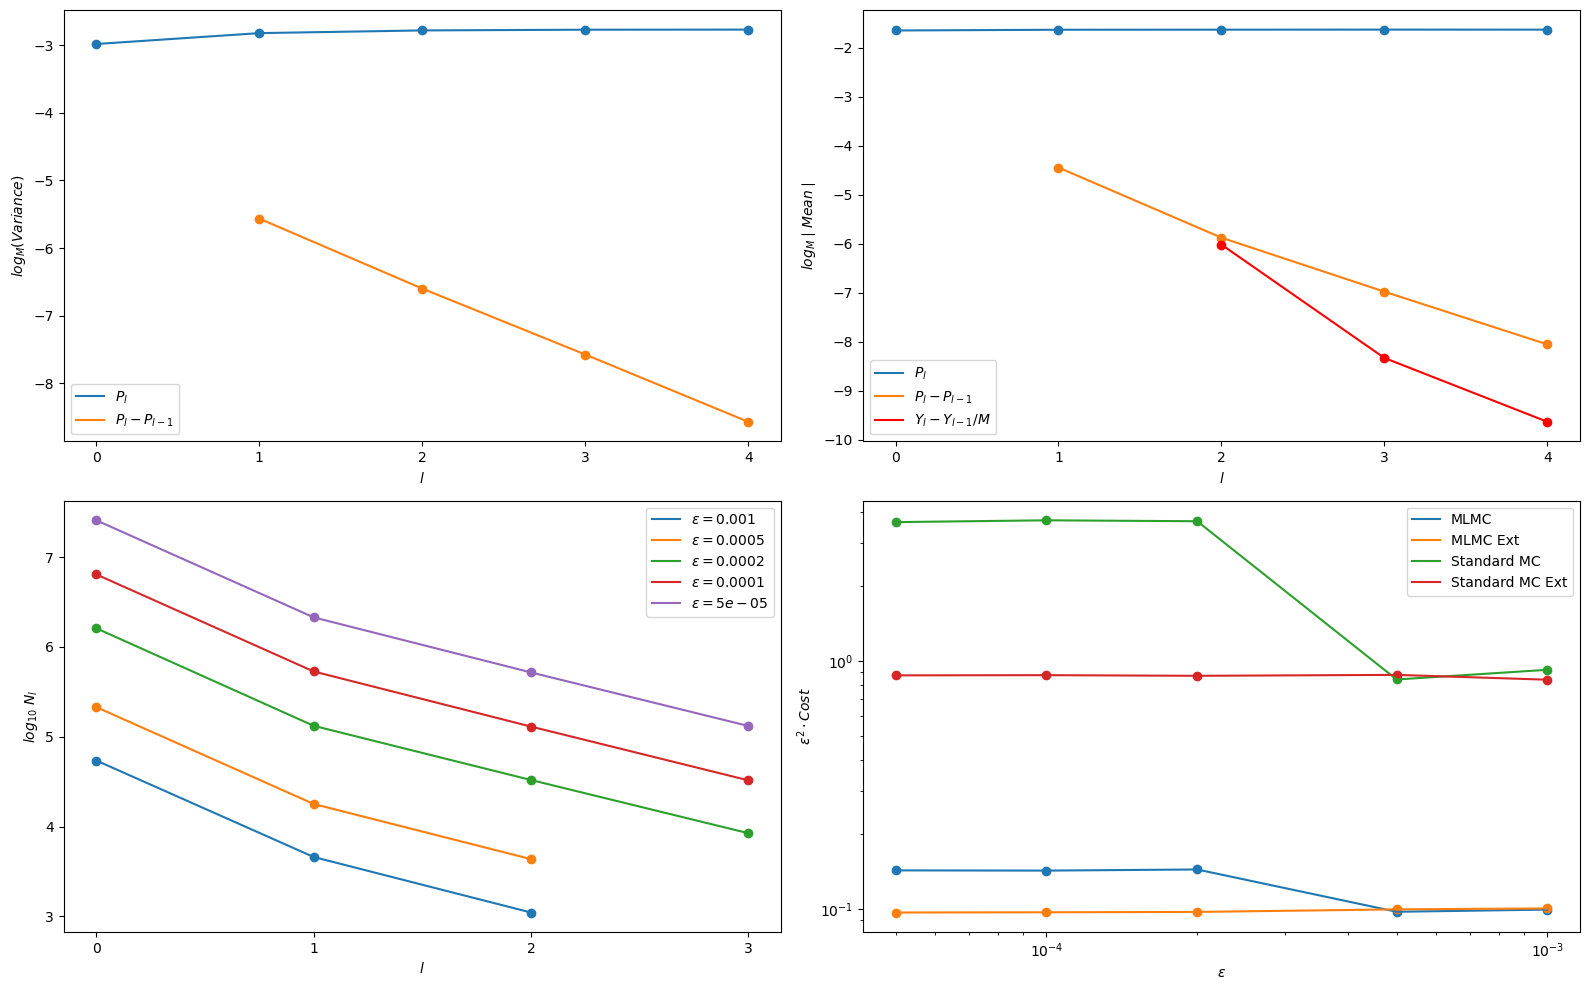

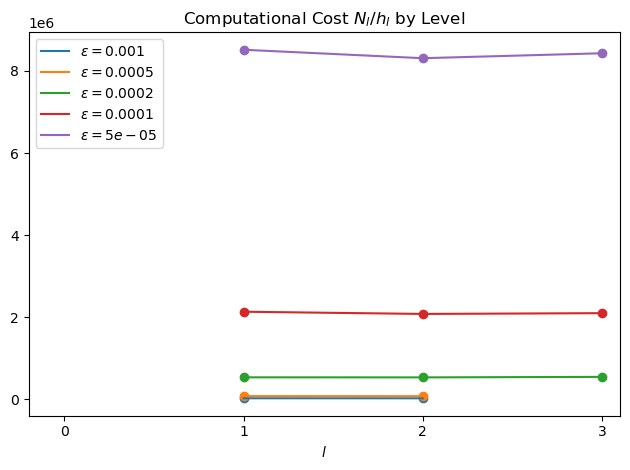

In [6]:
epss = np.array([0.001, 0.0005, 0.0002, 0.0001, 0.00005])
np.random.seed(0)
plot_graphs(lambda l, paths: simulate_P_l_diff(l, european_call, S0, r, sigma, T, paths), \
            lambda eps, model_sim, ext: estimate_price(european_call, model_sim, eps, ext, disp=False), \
            Black_Scholes_Call_Price, epss, 'GBM_call', 4*10**6, True)

l = 0 took 0.20249080657958984 seconds.
l = 1 took 0.7576842308044434 seconds.
l = 2 took 2.4219882488250732 seconds.
l = 3 took 8.355629205703735 seconds.
l = 4 took 58.8199417591095 seconds.
Eps = 0.001:
No Ext Estimate: 0.057653108299264594 (-0.6%) Ext Estimate: 0.057531490948724305 (-0.81%)
Time taken: 0.02480292320251465
----------------------------------------------------------------------------------------------------
Eps = 0.0005:
No Ext Estimate: 0.057075699893159394 (-1.59%) Ext Estimate: 0.057973467836768273 (-0.05%)
Time taken: 0.05584979057312012
----------------------------------------------------------------------------------------------------
Eps = 0.0002:
No Ext Estimate: 0.0576995357165536 (-0.52%) Ext Estimate: 0.05786676497792206 (-0.23%)
Time taken: 0.21682262420654297
----------------------------------------------------------------------------------------------------
Eps = 0.0001:
No Ext Estimate: 0.05757996609873019 (-0.72%) Ext Estimate: 0.05769355179004605 (-0.

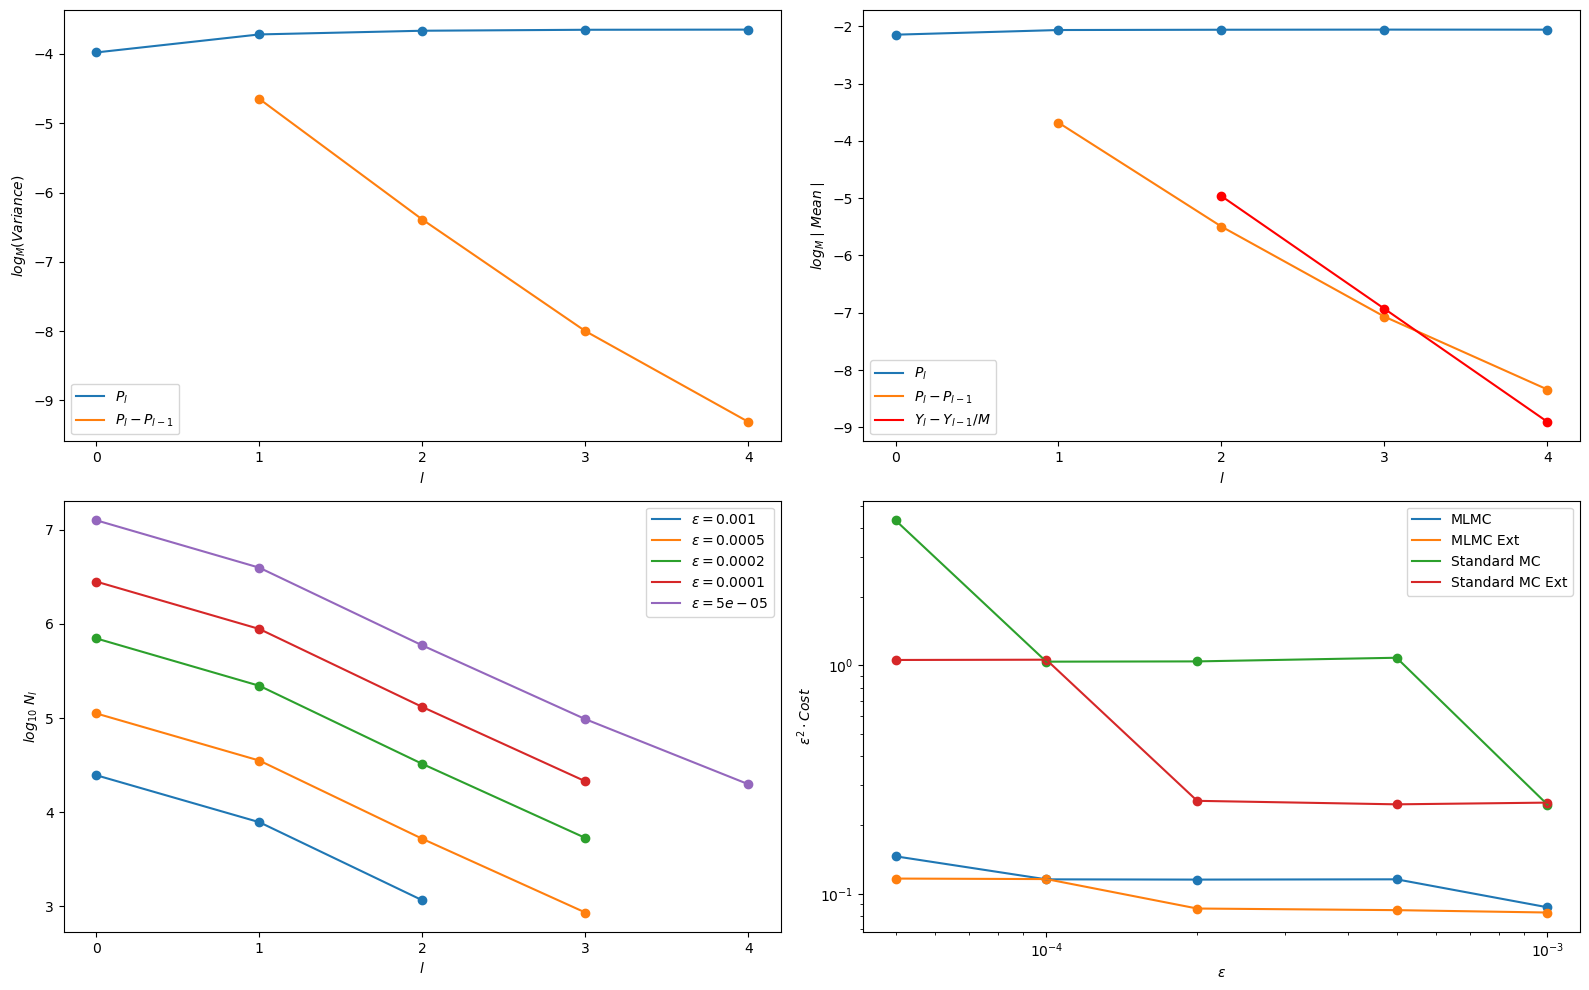

In [7]:
def asian_call(S):
    steps = S.shape[1]-1
    S_bar = (T/steps)*0.5*np.sum((S[:,:-1]+S[:,1:]), axis = 1)
    return np.maximum(S_bar-K, 0)

np.random.seed(0)
epss = np.array([0.001, 0.0005, 0.0002, 0.0001, 0.00005])
plot_graphs(lambda l, paths: simulate_P_l_diff(l, asian_call, S0, r, sigma, T, paths), \
            lambda eps, model_sim, ext: estimate_price(asian_call, model_sim, eps, ext, disp=False), \
            0.058, epss, 'GBM_asian_call')

l = 0 took 0.2539937496185303 seconds.
l = 1 took 0.7493994235992432 seconds.
l = 2 took 2.130305290222168 seconds.
l = 3 took 7.542204856872559 seconds.
l = 4 took 51.74191999435425 seconds.
Eps = 0.002:
No Ext Estimate: 0.17315185580181097 (0.57%) Ext Estimate: 0.17096489061819728 (-0.7%)
Time taken: 0.04247474670410156
----------------------------------------------------------------------------------------------------
Eps = 0.001:
No Ext Estimate: 0.17277914575945358 (0.35%) Ext Estimate: 0.17165510240893508 (-0.3%)
Time taken: 0.043683528900146484
----------------------------------------------------------------------------------------------------
Eps = 0.0005:
No Ext Estimate: 0.17203073356627546 (-0.08%) Ext Estimate: 0.17174217226127886 (-0.25%)
Time taken: 0.18578839302062988
----------------------------------------------------------------------------------------------------
Eps = 0.0002:
No Ext Estimate: 0.1720461416862773 (-0.07%) Ext Estimate: 0.17230268275151586 (0.08%)
Time

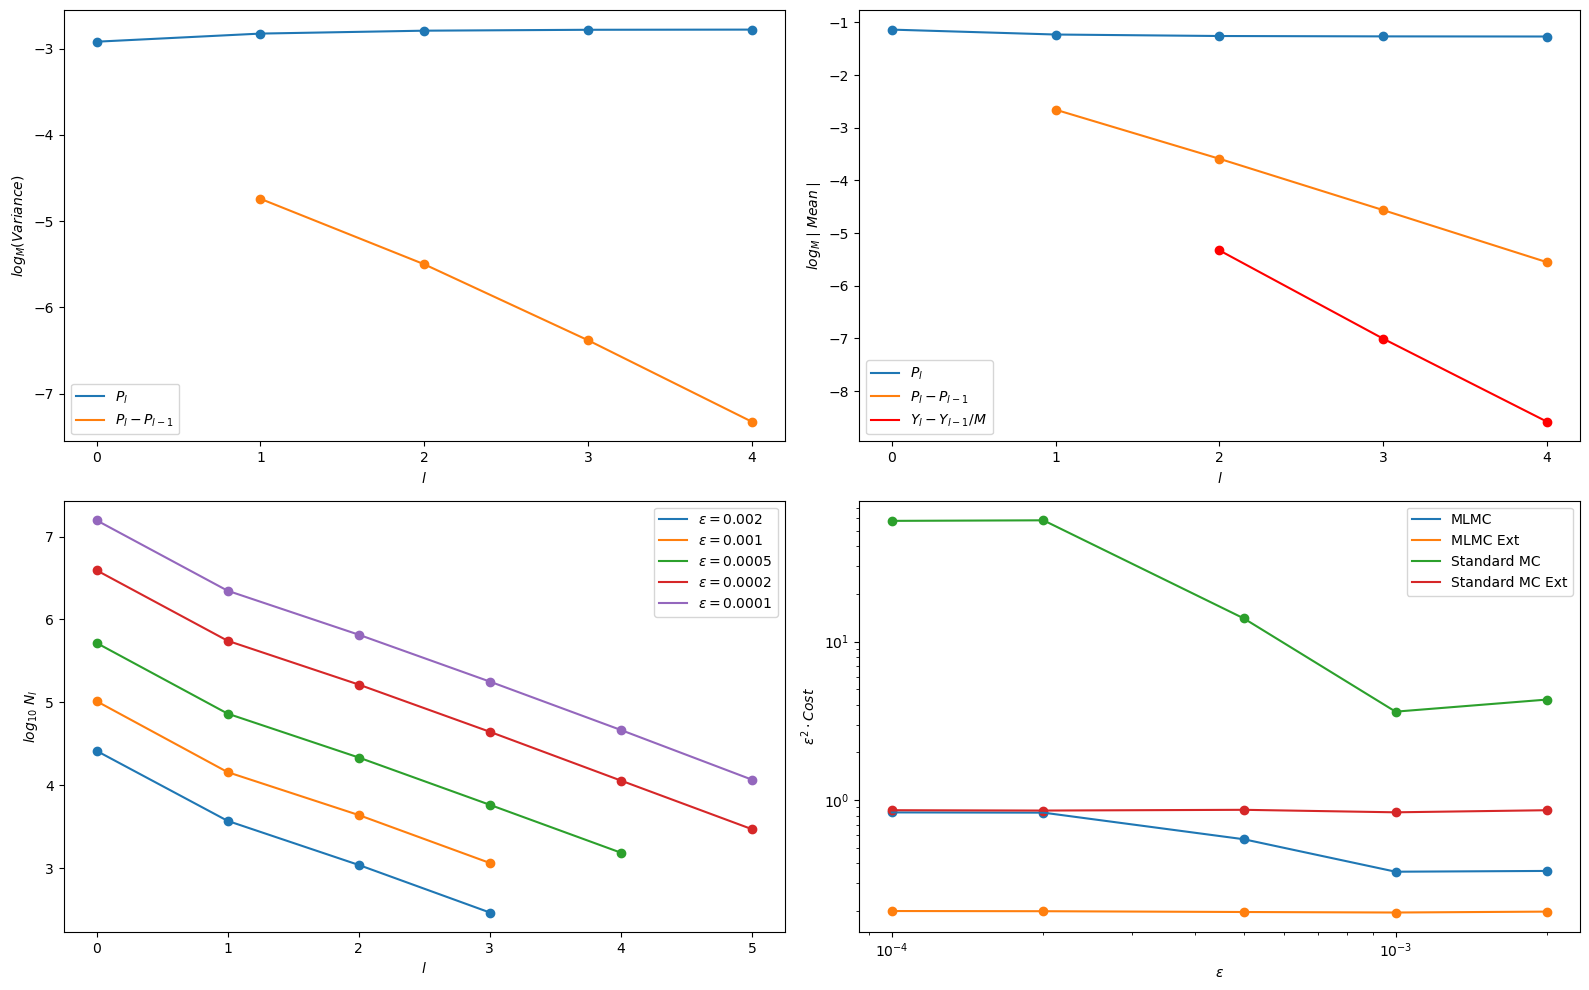

In [8]:
def lookback_call(S):
    beta = 0.5826
    timestep = T/(S.shape[1]-1)
    return S[:, -1] - np.min(S, axis=1)*(1-beta*sigma*np.sqrt(timestep))

np.random.seed(0)
epss = np.array([0.002, 0.001, 0.0005, 0.0002, 0.0001])
plot_graphs(lambda l, paths: simulate_P_l_diff(l, lookback_call, S0, r, sigma, T, paths), \
            lambda eps, model_sim, ext: estimate_price(lookback_call, model_sim, eps, ext, disp=False), \
            Black_Scholes_Lookback_Call_Price, epss, 'GBM_lookback_call')

l = 0 took 0.01699995994567871 seconds.
l = 1 took 0.05584239959716797 seconds.
l = 2 took 0.18228530883789062 seconds.
l = 3 took 0.7104165554046631 seconds.
l = 4 took 2.851247549057007 seconds.
Eps = 0.005:
No Ext Estimate: 0.5311546753127968 (-0.22%) Ext Estimate: 0.5226738353379695 (-1.81%)
Time taken: 0.020012378692626953
----------------------------------------------------------------------------------------------------
Eps = 0.002:
No Ext Estimate: 0.534456338851918 (0.4%) Ext Estimate: 0.5309094332195043 (-0.27%)
Time taken: 0.10551333427429199
----------------------------------------------------------------------------------------------------
Eps = 0.001:
No Ext Estimate: 0.5328576692275974 (0.1%) Ext Estimate: 0.5309503826148534 (-0.26%)
Time taken: 0.47499942779541016
----------------------------------------------------------------------------------------------------
Eps = 0.0005:
No Ext Estimate: 0.5326944718935932 (0.07%) Ext Estimate: 0.5321828240512984 (-0.03%)
Time tak

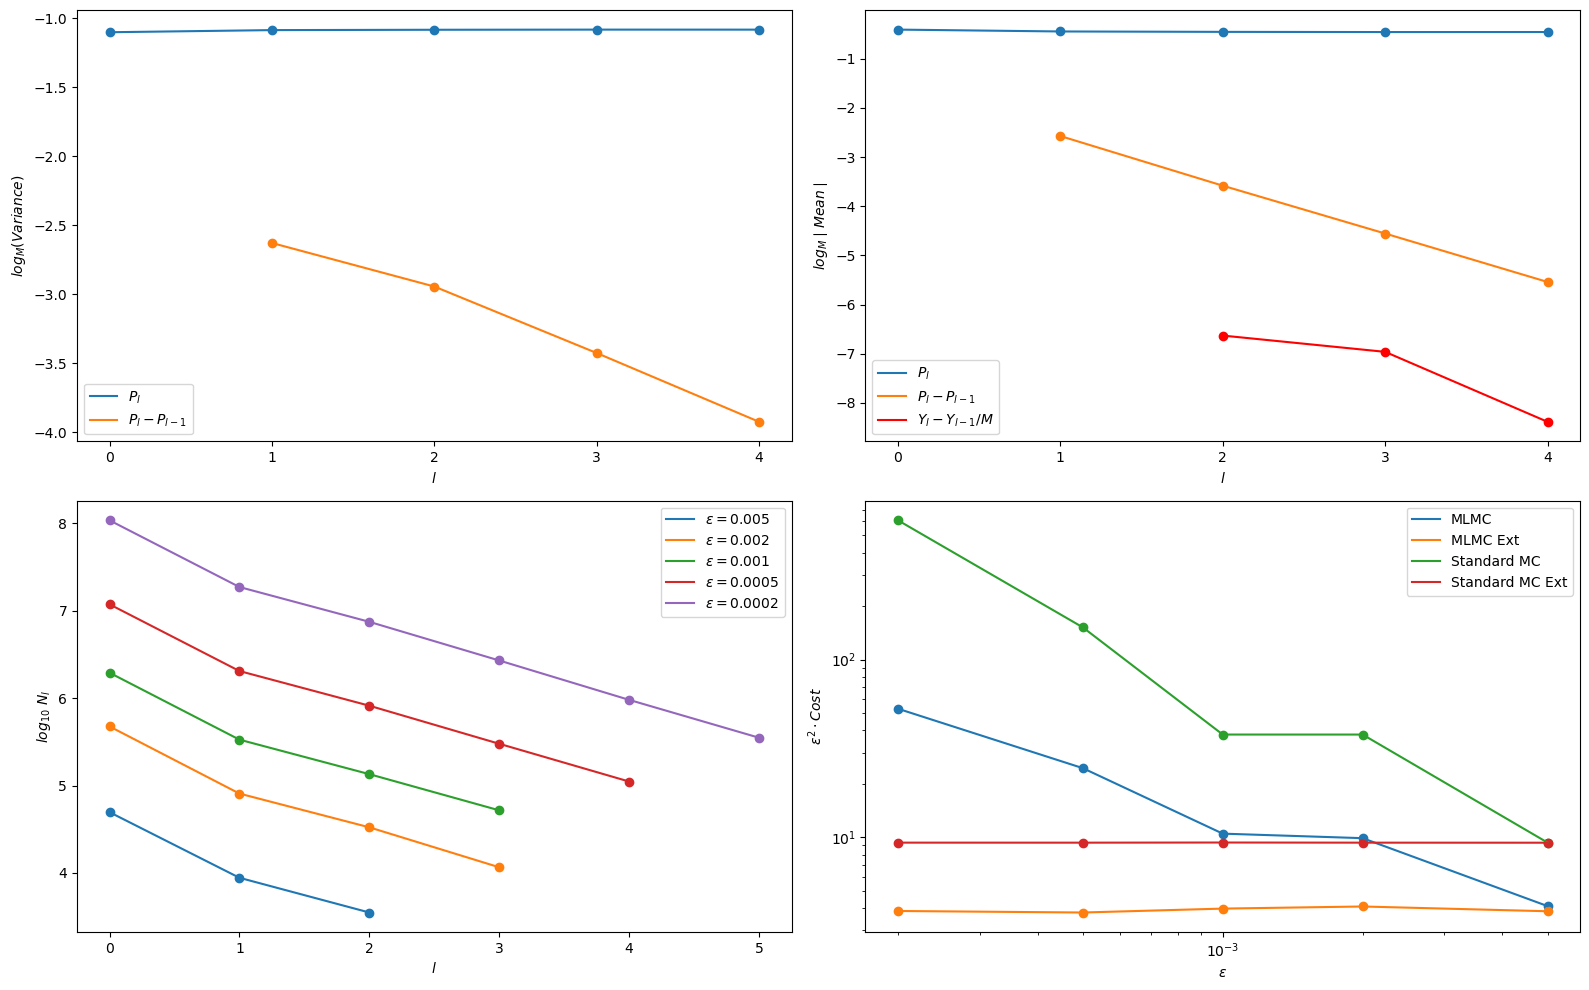

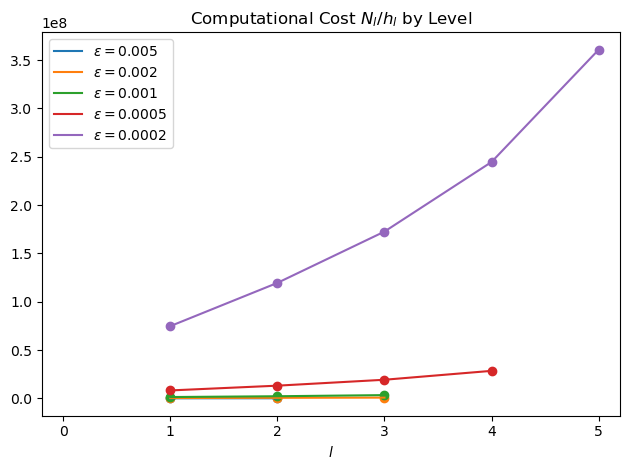

In [41]:
def digital_call(S):
    return (S[:, -1] >= K).astype(int)
    
np.random.seed(0)
epss = np.array([0.005, 0.002, 0.001, 0.0005, 0.0002])
plot_graphs(lambda l, paths: simulate_P_l_diff(l, digital_call, S0, r, sigma, T, paths), \
            lambda eps, model_sim, ext: estimate_price(digital_call, model_sim, eps, ext, disp=False), \
            Black_Scholes_Digital_Call_Price, epss, 'GBM_digital_call', 4*10**5, True)   # Decreased from 4*10^6 to 4*10^5 due to memory limitations

### Heston Stochastic Volatility

In [9]:
def simulate_P_l_diff_Heston(l, payoff, S0, V0, r, sigma, lambd, xi, rho, T, paths):

    steps = M**l

    #Generate correlated brownians
    W_t11 = normal(0, np.sqrt(T/steps), size=(paths, steps))
    W_t12 = rho*W_t11+np.sqrt(1-rho**2)*normal(0, np.sqrt(T/steps), size=(paths, steps))

    S_t1 = np.zeros((paths, steps+1))
    V_t1 = np.zeros((paths, steps+1))
    S_t1[:, 0] = S0
    V_t1[:, 0] = V0

    # Generate stock and variance paths incrementally
    for i in range(1, steps+1):
        sqrt_positive_V = np.sqrt(np.maximum(V_t1[:, i-1], 0))
        S_t1[:, i] = (1+r*T/steps + sqrt_positive_V*W_t11[:, i-1])*S_t1[:, i-1]
        V_t1[:, i] = sigma**2 + np.exp(-lambd*(T/steps))*((V_t1[:,i-1]-sigma**2)+xi*sqrt_positive_V*W_t12[:,i-1])
        
    payoffs1 = payoff(S_t1)
    del S_t1, V_t1
    if l == 0:
        return np.exp(-r*T)*payoffs1, np.exp(-r*T)*payoffs1
    
    # Group the Brownian increments in groups of M
    W_t21 = np.zeros((paths, steps//M))
    W_t22 = np.zeros((paths, steps//M))
    for j in range(M):
        W_t21 += W_t11[:, j::M]
        W_t22 += W_t12[:, j::M]
    del W_t11, W_t12
    
    S_t2 = np.zeros((paths, steps//M + 1))
    V_t2 = np.zeros((paths, steps//M + 1))
    S_t2[:, 0] = S0
    V_t2[:,0] = V0

    for i in range(1, steps//M + 1):
        sqrt_positive_V = np.sqrt(np.maximum(V_t2[:, i-1], 0))
        S_t2[:, i] = (1+r*M*T/steps + sqrt_positive_V*W_t21[:, i-1])*S_t2[:, i-1]
        V_t2[:, i] = sigma**2 + np.exp(-lambd*(M*T/steps))*((V_t2[:,i-1]-sigma**2)+xi*sqrt_positive_V*W_t22[:,i-1])
    payoffs2 = payoff(S_t2)
    
    return np.exp(-r*T)*payoffs1, np.exp(-r*T)*(payoffs1-payoffs2)

l = 0 took 0.0317683219909668 seconds.
l = 1 took 0.12444734573364258 seconds.
l = 2 took 0.6367273330688477 seconds.
l = 3 took 2.808812141418457 seconds.
l = 4 took 11.994092464447021 seconds.
Eps = 0.005:
No Ext Estimate: 0.10344496008804153 (-1.1%) Ext Estimate: 0.10710897741175009 (2.4%)
Time taken: 0.024337053298950195
----------------------------------------------------------------------------------------------------
Eps = 0.0005:
No Ext Estimate: 0.10419862122506159 (-0.38%) Ext Estimate: 0.1049322101507414 (0.32%)
Time taken: 0.06087779998779297
----------------------------------------------------------------------------------------------------
Eps = 0.0002:
No Ext Estimate: 0.10481601874435237 (0.21%) Ext Estimate: 0.10471358738224475 (0.11%)
Time taken: 0.6460146903991699
----------------------------------------------------------------------------------------------------
Eps = 0.0001:
No Ext Estimate: 0.10456303694631243 (-0.03%) Ext Estimate: 0.10464261027389693 (0.04%)
Tim

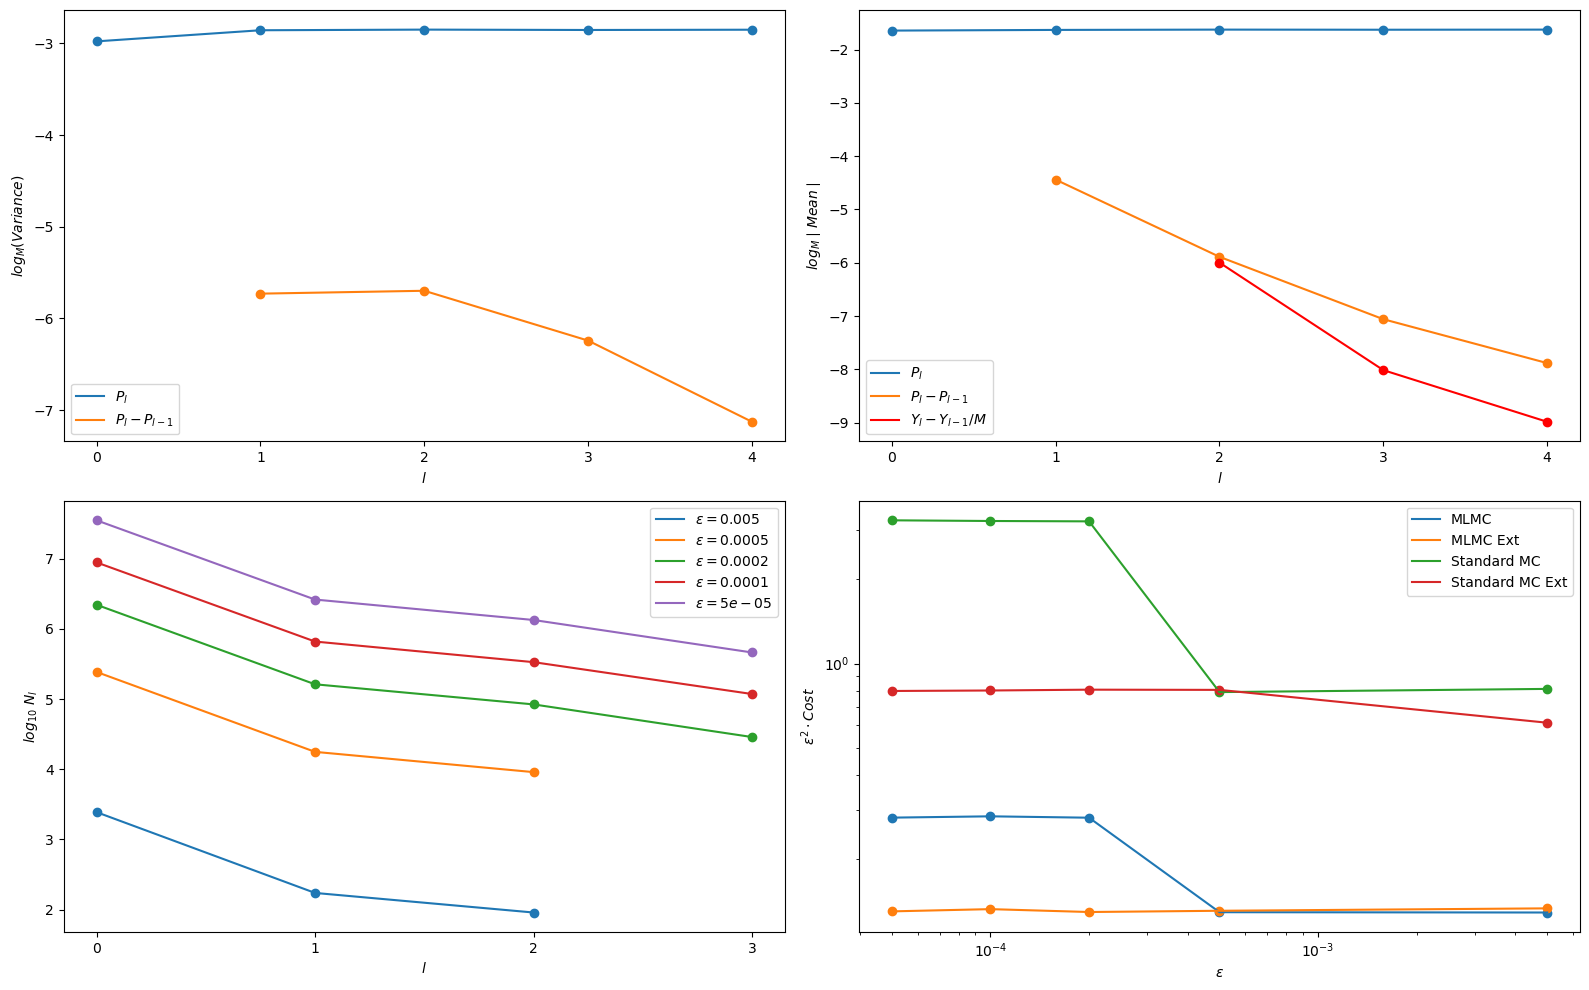

In [10]:
S0 = 1
V0 = 0.04
lambd = 5
xi = 0.25
rho = -0.5
K = 1
r = 0.05
sigma = 0.2
T = 1

np.random.seed(0)
heston_call_price = heston_price(S0, V0, sigma**2, lambd, xi, r, rho, T, K)
epss = np.array([0.005, 0.0005, 0.0002, 0.0001, 0.00005])
plot_graphs(lambda l, paths: simulate_P_l_diff_Heston(l, european_call, S0, V0, r, sigma, lambd, xi, rho, T, paths), \
            lambda eps, model_sim, ext: estimate_price(european_call, model_sim, eps, ext, disp=False), 
            float(heston_call_price), epss, 'Heston_call', 4*10**5)   # Decreased from 4*10^6 to 4*10^5 due to memory limitations

### Milstein Scheme

In [11]:
def simulate_P_l_diff_Milstein(l, payoff, S0, r, sigma, T, paths):
    steps = M**l
    W_t1 = normal(0, np.sqrt(T/steps), size=(paths, steps))
    S_t1 = np.zeros((paths, steps+1))
    S_t1[:, 0] = S0
    # Same as before but with an additional adjustment term
    S_t1[:, 1:] = S0 * np.cumprod(1+r*T/steps + sigma*W_t1 + 0.5*(sigma**2)*(W_t1**2 - T/steps), axis=1)

    payoffs1 = payoff(S_t1)
    del S_t1
    if l == 0:
        return np.exp(-r*T)*payoffs1, np.exp(-r*T)*payoffs1

    W_t2 = np.zeros((paths, steps//M))
    # Group the Brownian increments in groups of M
    for j in range(M):
        W_t2 += W_t1[:, j::M]
    del W_t1
    S_t2 = np.zeros((paths, steps//M + 1))
    S_t2[:, 0] = S0
    S_t2[:, 1:] = S0 * np.cumprod(1+r*(M*T/steps) + sigma*W_t2 + 0.5*(sigma**2)*(W_t2**2 - M*T/steps), axis=1)
    del W_t2
    payoffs2 = payoff(S_t2)
    del S_t2
    
    return np.exp(-r*T)*payoffs1, np.exp(-r*T)*(payoffs1-payoffs2)

l = 0 took 0.19314289093017578 seconds.
l = 1 took 0.7070412635803223 seconds.
l = 2 took 2.620903491973877 seconds.
l = 3 took 9.562195539474487 seconds.
l = 4 took 200.7887065410614 seconds.
Eps = 0.001:
No Ext Estimate: 0.10426529756037495 (-0.23%) Ext Estimate: 0.10415082859988477 (-0.34%)
Time taken: 0.03254866600036621
----------------------------------------------------------------------------------------------------
Eps = 0.0005:
No Ext Estimate: 0.10359047237613676 (-0.88%) Ext Estimate: 0.10446144391488331 (-0.04%)
Time taken: 0.03969430923461914
----------------------------------------------------------------------------------------------------
Eps = 0.0002:
No Ext Estimate: 0.10439820346909526 (-0.1%) Ext Estimate: 0.10443420405774409 (-0.07%)
Time taken: 0.19969820976257324
----------------------------------------------------------------------------------------------------
Eps = 0.0001:
No Ext Estimate: 0.10431714883723996 (-0.18%) Ext Estimate: 0.10451467568087733 (0.01%)

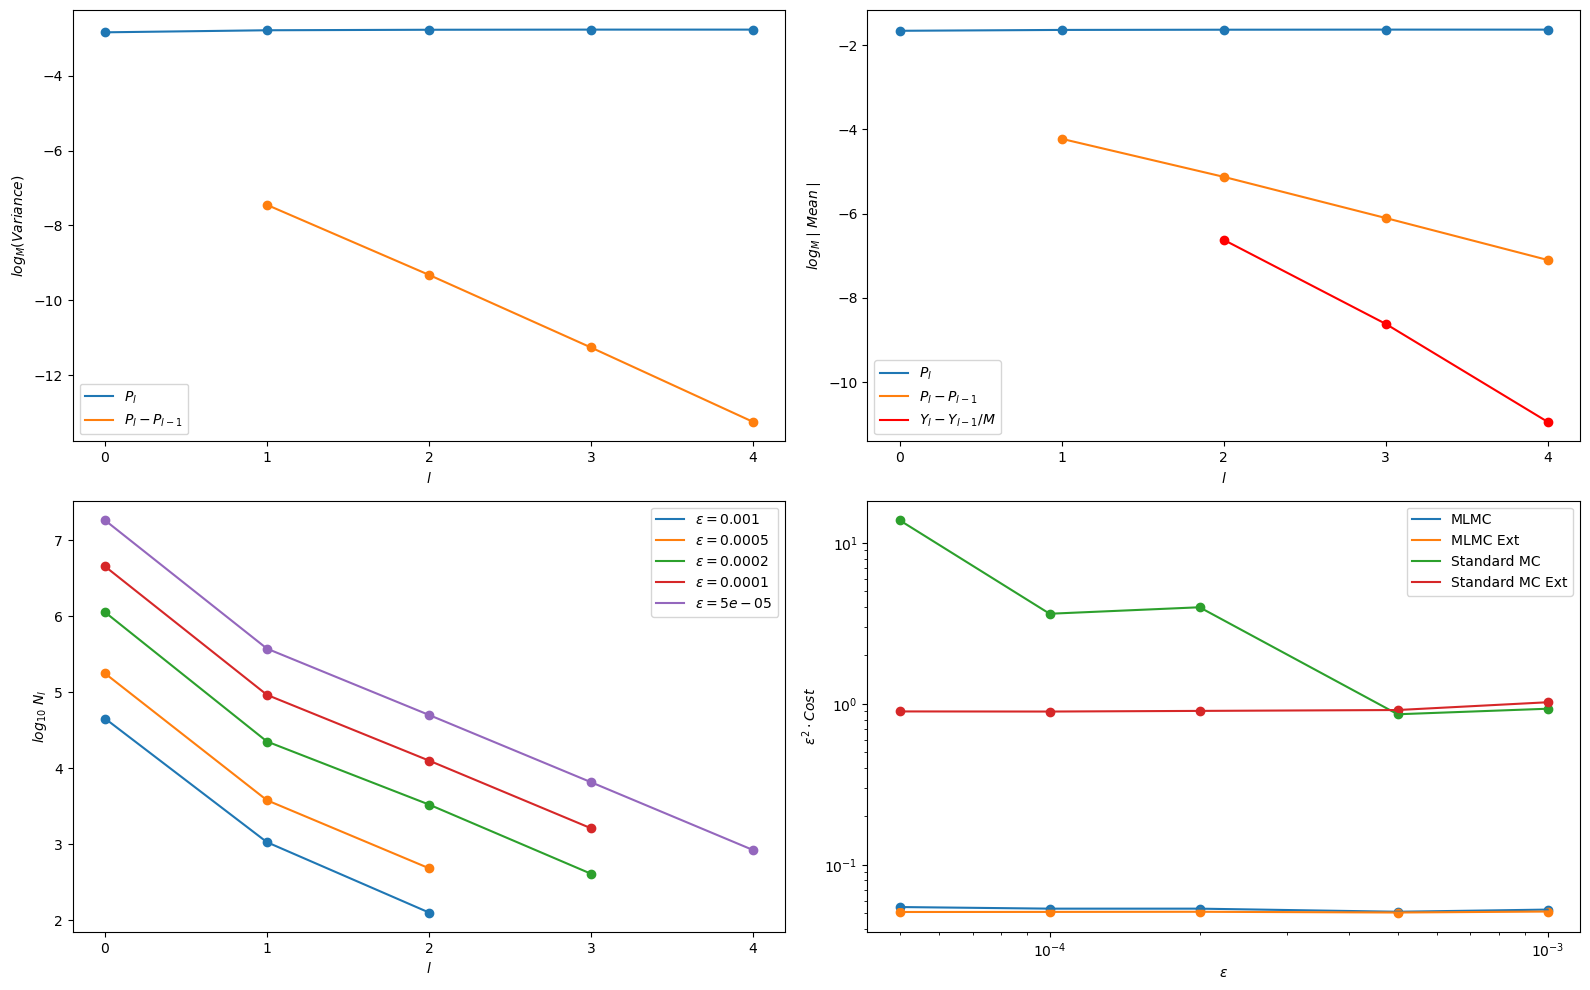

In [13]:
epss = np.array([0.001, 0.0005, 0.0002, 0.0001, 0.00005])
np.random.seed(0)
plot_graphs(lambda l, paths: simulate_P_l_diff_Milstein(l, european_call, S0, r, sigma, T, paths), \
            lambda eps, model_sim, ext: estimate_price(european_call, model_sim, eps, ext, disp=False), \
            Black_Scholes_Call_Price, epss, 'GBM_Milstein_call')

l = 0 took 0.02104473114013672 seconds.
l = 1 took 0.06947875022888184 seconds.
l = 2 took 0.23663091659545898 seconds.
l = 3 took 0.9197070598602295 seconds.
l = 4 took 3.756415367126465 seconds.
Eps = 0.005:
No Ext Estimate: 0.5357403039842602 (0.64%) Ext Estimate: 0.5324549853536071 (0.02%)
Time taken: 0.01659250259399414
----------------------------------------------------------------------------------------------------
Eps = 0.002:
No Ext Estimate: 0.5328659469340452 (0.1%) Ext Estimate: 0.5331334825234636 (0.15%)
Time taken: 0.029152631759643555
----------------------------------------------------------------------------------------------------
Eps = 0.001:
No Ext Estimate: 0.5333750653588747 (0.2%) Ext Estimate: 0.5320889856796546 (-0.04%)
Time taken: 0.08063173294067383
----------------------------------------------------------------------------------------------------
Eps = 0.0005:
No Ext Estimate: 0.5328230876604027 (0.09%) Ext Estimate: 0.5322827809614897 (-0.01%)
Time taken

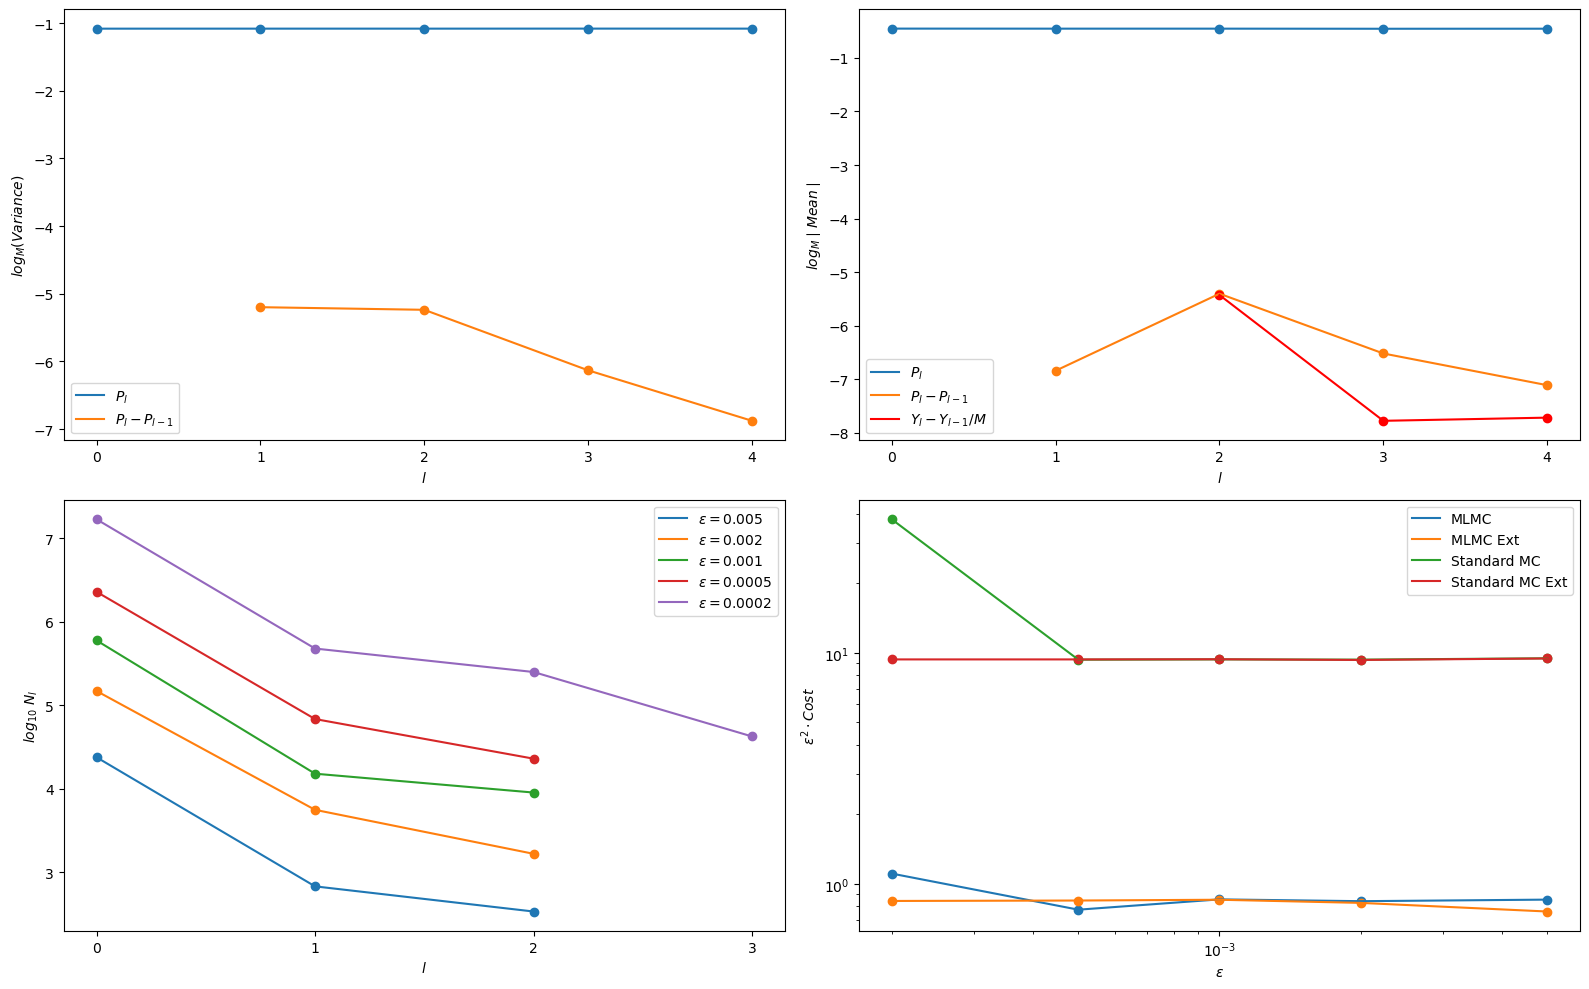

In [12]:
def digital_call(S):
    return (S[:, -1] >= K).astype(int)

np.random.seed(0)
epss = np.array([0.005, 0.002, 0.001, 0.0005, 0.0002])
plot_graphs(lambda l, paths: simulate_P_l_diff_Milstein(l, digital_call, S0, r, sigma, T, paths), \
            lambda eps, model_sim, ext: estimate_price(digital_call, model_sim, eps, ext, disp=False), \
            Black_Scholes_Digital_Call_Price, epss, 'GBM_Milstein_digital_call', 4*10**5)   # Decreased from 4*10^6 to 4*10^5 due to memory limitations

## Quantum


In [4]:
from scipy.stats import norm
from itertools import product

from qiskit.circuit.library.standard_gates import mcry
from qiskit.circuit.add_control import add_control
from qiskit import QuantumCircuit
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit.circuit.library import LinearAmplitudeFunction, Initialize, UnitaryGate
from qiskit.quantum_info import Statevector, Operator


In [5]:
def QMC_european_call(St, epsilon):

    n = int(np.log2(len(St))) # Number of qubits
    payoff_vals = np.maximum(St-K,0)
    if np.all(payoff_vals == 0):
        normalized_payoff_vals = payoff_vals
    else:
        normalized_payoff_vals = (payoff_vals)/(np.sum(payoff_vals))

    probs = [1/(2**n) for _ in range(2**n)]
    probabilities_estimator = []
    for i in range(2**(n)):
        probabilities_estimator.append(probs[i]*(1-normalized_payoff_vals[i]))
        probabilities_estimator.append(probs[i]*normalized_payoff_vals[i])

    # We finally construct the European call circuit with the entire state preparation

    distribution_estimator = QuantumCircuit(n+1)
    initialize_estimator = Initialize(np.sqrt(probabilities_estimator)) # Initializes a state with the probabilities as desired
    distribution_estimator = initialize_estimator.gates_to_uncompute().inverse() # Defines the circuit with the gates required to build the state in the form of unitary gates
    european_call = QuantumCircuit(n+1)
    european_call.append(distribution_estimator, range(n+1))
    QAE_prep_call = EstimationProblem(state_preparation = european_call, objective_qubits = [0]) # Arguments refer to state preparation,~
    # index of qubit to measure (first qubit in this case due to initialization procedure of circuit) 

    # Set confidence level (function needs a confidence level to run even if value is not wanted)
    alpha = 0.05

    QAE = IterativeAmplitudeEstimation(epsilon, alpha)
    result = QAE.estimate(QAE_prep_call).estimation*np.sum(payoff_vals)

    return result


def simulate_P_l_diff_Quantum(l, payoff, S0, r, sigma, T, paths):
    
    steps = M**l
    W_t1 = normal(0, np.sqrt(T/steps), size=(paths, steps))
    S_t1 = np.zeros((paths, steps+1))
    S_t1[:, 0] = S0
    S_t1[:, 1:] = S0 * np.cumprod(1+r*T/steps + sigma*W_t1, axis=1)

    payoffs1 = payoff(S_t1)
    if l == 0:
        return np.exp(-r*T)*payoffs1, np.exp(-r*T)*payoffs1, S_t1[:,-1], np.zeros_like(S_t1[:,-1])

    W_t2 = np.zeros((paths, steps//M))
    for j in range(M):
        W_t2 += W_t1[:, j::M]
    S_t2 = np.zeros((paths, steps//M + 1))
    S_t2[:, 0] = S0
    S_t2[:, 1:] = S0 * np.cumprod(1+r*(M*T/steps) + sigma*W_t2, axis=1)

    payoffs2 = payoff(S_t2)

    return np.exp(-r*T)*payoffs1, np.exp(-r*T)*(payoffs1-payoffs2), S_t1[:,-1], S_t2[:,-1]

def estimate_price_Quantum(payoff, eps=0.001, extrapolation=False, disp=True):

    L = 0
    N_initial = 2**1
    target_error = (1/np.sqrt(2))*(M-1)*eps
    target_error_extrapolation = (1/np.sqrt(2))*(M**2-1)*eps
    St_1s = []
    St_2s = []
    P_ls = []
    P_diffs = []
    P_diffs_sum = []
    P_diffs_calc = []
    max_N_ls = np.array([], dtype='int64')
    N_ls = np.array([], dtype='int64')
    V_ls = np.array([])
    h_ls = np.array([])
    while True:
        start = time.time()
        P_l, diff, St_1, St_2 = simulate_P_l_diff_Quantum(L, payoff, S0, r, sigma, T, N_initial)
        print(St_1, St_2)
        P_ls.append(P_l)
        P_diffs.append(diff)
        St_1s.append(St_1)
        St_2s.append(St_2)
        total = np.sum(diff)
        P_diffs_sum.append(total)
        V_ls = np.concatenate((V_ls, [(1/(N_initial-1))*np.sum((diff-total/N_initial)**2)]))
        h_ls = np.concatenate((h_ls, [M**(-L)]))
        max_N_ls = np.concatenate((max_N_ls, [N_initial]))
        N_ls = np.concatenate((N_ls, [N_initial]))
        P_diffs_calc.append(QMC_european_call(St_1,eps)-QMC_european_call(St_2,eps))

        new_N_ls = 2**np.ceil(np.log2(np.ceil(2/(eps**2) * np.sqrt(V_ls*h_ls) * np.sum(np.sqrt(V_ls/h_ls))).astype(int)))
        if disp:
            print(new_N_ls)
        for i in range(L+1):
            if new_N_ls[i] > max_N_ls[i]:
                P_l, diff, St_1, St_2 = simulate_P_l_diff_Quantum(i, payoff, S0, r, sigma, T, int(2**np.ceil(np.log2(new_N_ls[i]-max_N_ls[i]))))
                P_ls[i] = np.concatenate((P_ls[i], P_l))
                P_diffs[i] = np.concatenate((P_diffs[i], diff))
                St_1s[i] = St_1
                St_2s[i] = St_2
                P_diffs_sum[i] += np.sum(P_diffs[i][N_ls[i]:])
                P_diffs_calc[i] = QMC_european_call(St_1,eps)-QMC_european_call(St_2,eps)
                V_ls[i] = np.std(P_diffs[i], ddof=1)**2
            elif new_N_ls[i] > N_ls[i]:
                P_diffs_sum[i] += np.sum(P_diffs[i][N_ls[i]:new_N_ls[i]])
                P_diffs_calc[i] = QMC_european_call(St_1s[i],eps)-QMC_european_call(St_2s[i],eps)
                V_ls[i] = np.std(P_diffs[i][:new_N_ls[i]], ddof=1)**2
            else:
                P_diffs_sum[i] -= np.sum(P_diffs[i][new_N_ls[i]:N_ls[i]])
                V_ls[i] = np.std(P_diffs[i][:new_N_ls[i]], ddof=1)**2
        #N_ls = np.maximum(N_ls, new_N_ls)
        N_ls = new_N_ls
        max_N_ls = np.maximum(max_N_ls, new_N_ls)

        if L >= 2:
            if extrapolation:
                if np.abs(np.sum(P_diffs_calc) - np.sum(P_diffs_calc[:-1])) < target_error_extrapolation:
                    if disp:
                        print(f'L = {L} took {time.time()-start} seconds.')
                    P_ls, P_diffs = [elem[:N_ls[i]] for i, elem in enumerate(P_ls)], [elem[:N_ls[i]] for i, elem in enumerate(P_diffs)]
                    return np.sum(P_diffs_calc) + (1/(M-1))*P_diffs_calc[-1], V_ls, N_ls, P_ls, P_diffs
            else:
                if np.abs(np.sum(P_diffs_calc[:-1])) < target_error and np.abs(P_diffs_calc[-1]) < target_error:
                    if disp:
                        print(f'L = {L} took {time.time()-start} seconds.')
                    P_ls, P_diffs = [elem[:N_ls[i]] for i, elem in enumerate(P_ls)], [elem[:N_ls[i]] for i, elem in enumerate(P_diffs)]
                    return np.sum(P_diffs_calc), V_ls, N_ls, P_ls, P_diffs
        if disp:
            print(f'L = {L} took {time.time()-start} seconds.')
        L += 1

In [6]:
a,b, St1, St2 = simulate_P_l_diff_Quantum(1, european_call, S0, r, sigma, T, 2**13)

In [8]:
print("Quantum Monte Carlo Estimate vs Classical Monte Carlo Estimate: ", QMC_european_call(St1, 0.001), np.sum(np.maximum(St1-K,0)/(2**13)))

c:\Users\Usuario\anaconda3\Lib\site-packages\qiskit_algorithms\amplitude_estimators\iae.py:274: UserWarning: No sampler provided, defaulting to Sampler from qiskit.primitives
  warnings.warn("No sampler provided, defaulting to Sampler from qiskit.primitives")


Quantum Monte Carlo Estimate vs Classical Monte Carlo Estimate:  0.11119928528594461 0.11119928528029674


In [ ]:
# Extremely slow due to lack of vectorization in Qiskit, takes too long to get useful results
estimate_price_Quantum(european_call, eps=0.0001, extrapolation=False, disp=True)

[0.76488358 1.44628629] [0. 0.]
[33554432.]
